In [ ]:
import sys
from os.path import expanduser, join

# --- Try the preferred import path ---
try:
    import find_jcmwave as jcmwave

    USING_FIND_JCMWAVE = True

except ImportError:
    USING_FIND_JCMWAVE = False

    # --- Fallback: manually append JCMsuite Python path ---
    home = expanduser("~")
    jcm_root = join(home, "JCMwave/JCMsuite_6_4_8/ThirdPartySupport/Python")
    sys.path.append(jcm_root)

    try:
        import jcmwave
    except ImportError as e:
        raise ImportError(
            "Could not import jcmwave. Tried find_jcmwave and manual path.\n"
            f"Checked fallback path: {jcm_root}"
        ) from e

# Optional: print which path was used
if USING_FIND_JCMWAVE:
    print("Imported jcmwave via find_jcmwave")
else:
    print(f"Imported jcmwave via manual path: {jcm_root}")

Imported jcmwave via find_jcmwave


In [ ]:
import sys
from os.path import expanduser, join

import find_jcmwave as jcmwave
import matplotlib.pyplot as plt
import numpy as np
import pint

import JCM_models.jcm_plotting_utils as JCMgrid
import JCM_models.xray_compounds as xc
from JCM_models import (
    Cartesian,
    PostProcess,
    Shape,
    ShapeGenerator,
    SimulationResult,
    Source,
    write_project_files,
)

unit = pint.UnitRegistry()

import matplotlib as mpl
import pandas as pd

mpl.rcParams["font.family"] = ["sans"]
mpl.rcParams["font.serif"] = ["DejaVu Sans"]
jcmwave.daemon.shutdown()

In [26]:
# Generates the project files for the JCMsuite simulation, adjust the name of the folder if necessary
write_project_files("JCMfolder_test")


project.jcmpt written to JCMfolder_test/project.jcmpt
sources.jcmt written to JCMfolder_test/sources.jcmt
layout.jcmt written to JCMfolder_test/layout.jcmt
materials.jcmt written to JCMfolder_test/materials.jcmt


In [27]:
# Set up the JCMsuite daemon for parallel computing, adjust the parameters if necessary, take number of CPU cores into account
jcmwave.daemon.shutdown()
jcmwave.daemon.add_workstation(
    Hostname="localhost",
    Multiplicity=1,
    NThreads=12,
)

[1722230772]

In [28]:
jcmwave.info()


Copyright (c) 2001-2026 JCMwave GmbH, Berlin. All Rights Reserved



             JCMROOT : /home/hduva/.jcmwave
    JCMsuite version : 6.8.1
            Buildtag : linux64-2026.03.16.09.47
         Number CPUs : 32
      Number threads : default
      License server : 131.243.191.134:4000





<Axes: >

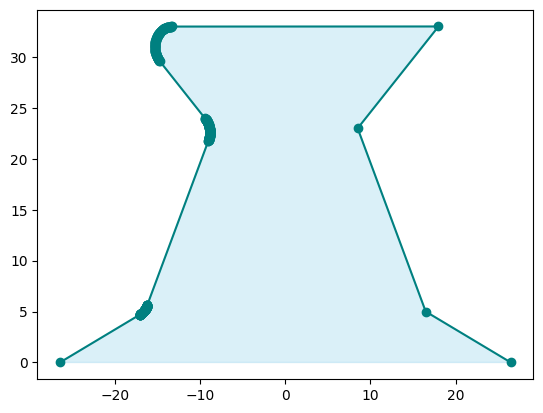

In [ ]:
params = {
    "height": [5, 18, 10],
    "width": [53, 33, 17, 36],
    "corner_radii": {4: 2, 5: 2, 6: 2},
    "n": 100,
}
fig, ax = plt.subplots()
gen = ShapeGenerator("stack_trapezoids", params)
coords = gen.generate()
gen.plot(ax=ax, title="Trapezoid with Side Wall Angle")

In [30]:
# Example usage of the Source class

s_nm = Source(532, [1, 0], 45, 0, unit="nm")
s_eV = Source(
    2.33,
    [0, 1],
    60,
    90,
    unit="eV",
    incidence="FromBelow",
    PowerFluxScaling="UnitNormal",
)

# print(s_nm.describe())
print()
print(s_eV.to_jcm())




    SourceBag {
    Source {
    ElectricFieldStrength {
        PlaneWave {
        Lambda0 = 5.32121023318456e-07
        SP = [0 1]
        ThetaPhi = [60, 90]
        3DTo2D = yes
        Incidence = FromBelow
      PowerFluxScaling = UnitNormal
        }
    }
    }
    }
    


In [31]:
# Example usage of the Shape class
thick = np.array([20, 35, 1.2])
rough = np.array([0, 0, 0, 0])
wl = [13.5, 11]

nk_resist = [1 - 0.023 + 0.00419j, 1 - 0.023 + 0.00419j]
nk_Chaucer = [1 - 0.0226 + 0.0048j, 1 - 0.023 + 0.00419j]
nk_SOG = [1 - 0.0195 - 0.006j, 1 - 0.023 + 0.00419j]
nk_sub = np.conjugate(xc.refractive_index("Si", wl * unit.nm, density=2.33))
nk_sub_oxid = np.conjugate(
    xc.refractive_index("SiO2", wl * unit.nm, density=2.0929729034348785)
)

thick_noUL = np.array([20, 1.2])
rough_noUL = np.array([0, 0, 0])
keys = {
    "uol1": 1e-9,
    "fem_deg": 4,
}

# keys['energy'] = energy[i_taken_energy].to(unit.keV, 'sp').magnitude
# print(keys['energy'])
keys["pol"] = [1, 0]  # 1,0 s pol 0,1 p pol
keys["lamb"] = wl[0] * 1e-9
keys["slc"] = 1


pitch = 50
substrate_offset = 30
vacuum_offset = 30
y = 60
slc = 1

computional_domain = ShapeGenerator(
    "rectangle", {"height": y, "width": pitch}, offset_y=-15
).flatten(centered=True)
substrate = ShapeGenerator(
    "rectangle", {"height": 10, "width": pitch}, offset_y=-10
).flatten(centered=True)
substrate_oxide = ShapeGenerator("rectangle", {"height": 2, "width": pitch}).flatten(
    centered=True
)
bsplines = ShapeGenerator(
    "bsplines",
    {"control_points": [(15, 0), (10, 10), (-10, 10), (-10, 0)]},
    offset_y=30,
).flatten(centered=True)
trapzoid_stack = ShapeGenerator(
    "stack_trapezoids",
    {"height": [20, 10], "width": [20, 10, 20], "corner_radii": {3: 2.0, 2: 2.0}},
).flatten(centered=True)

gradient_dict = {
    "max_depth": 3,
    "exponent": 2,
    "permittivity_surface": np.square(nk_sub_oxid),
    "uol": keys["uol1"],
}

shape = [
    Shape(
        "ComputationalDomain",
        domain_id=1,
        priority=-1,
        side_length_constraint=slc,
        points=computional_domain,
        nk=1,
        boundary=["Transparent", "Periodic", "Transparent", "Periodic"],
    ),
    Shape(
        "substrate",
        domain_id=2,
        priority=1,
        side_length_constraint=slc,
        points=substrate,
        nk=nk_sub,
    ),
    Shape(
        "substrate_oxide",
        domain_id=3,
        priority=2,
        side_length_constraint=slc,
        points=substrate_oxide,
        nk=nk_sub_oxid,
    ),
    Shape(
        "UL",
        domain_id=4,
        priority=2,
        side_length_constraint=slc,
        points=bsplines,
        nk=nk_SOG,
    ),
    Shape(
        "resist",
        domain_id=5,
        priority=2,
        side_length_constraint=slc,
        points=trapzoid_stack,
        nk=nk_resist,
        gradient_dict=gradient_dict,
    ),
]
shape[0].domain_id
keys["shape"] = shape
keys["source"] = [s_eV]
keys["energy_index"] = 1

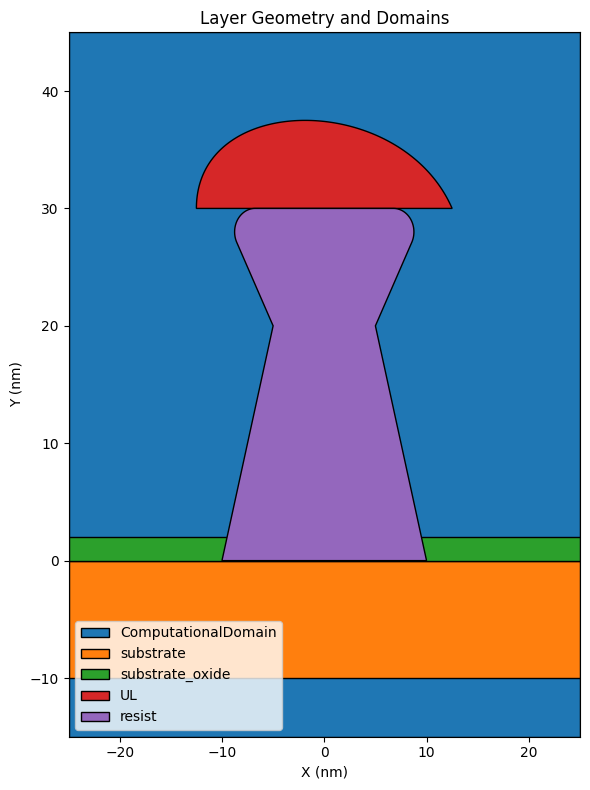

In [32]:
import matplotlib.pyplot as plt

# Create a shared figure and axis
fig, ax = plt.subplots(figsize=(6, 8))

# Plot each shape
for s in shape[:]:
    # s.plot(ax=ax)
    s.plot_colored_geometry(ax=ax)

# Final touches
ax.set_xlim(-pitch / 2, pitch / 2)
ax.set_ylim(-15, 45)
ax.set_xlabel("X (nm)")
ax.set_ylabel("Y (nm)")
ax.set_title("Layer Geometry and Domains")
ax.legend()
# ax.grid(True)
plt.tight_layout()
plt.show()

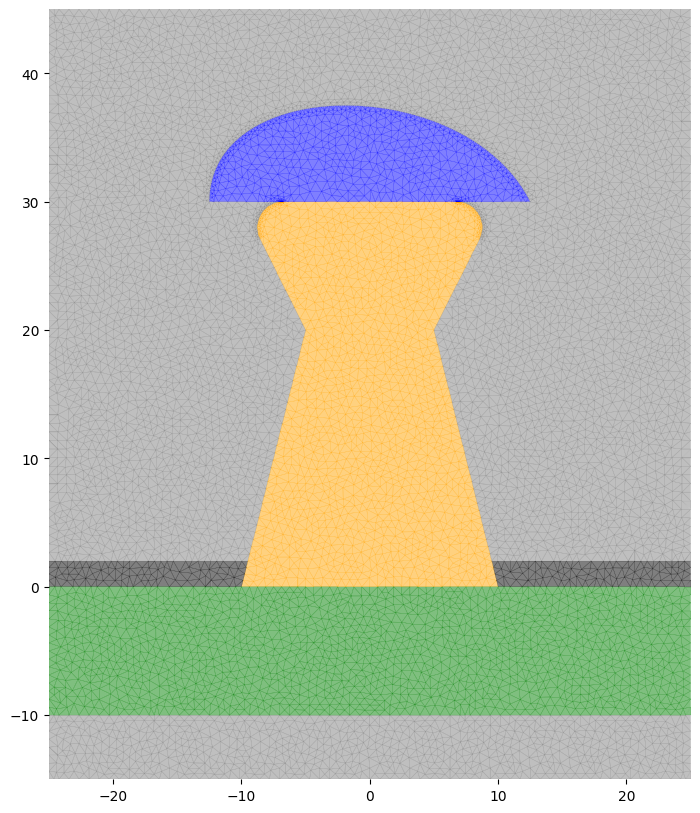

In [33]:
jcmwave.geo("./JCMfolder_test/", keys=keys)
fig, ax = plt.subplots(figsize=(10, 10))

JCMgrid.plot_grid(
    "./JCMfolder_test/grid.jcm",
    ax=ax,
    colors={1: "grey", 2: "green", 3: "black", 4: "blue", 5: "orange", 6: "pink"},
    alpha=0.5,
    lw=0.2,
)
ax.set_xlim(-pitch / 2, pitch / 2)
ax.set_ylim(-15, 45)
ax.set_frame_on(False)
# remove ticks and labels
# ax.set_xticks([])
# ax.set_yticks([])
ax.set_aspect("equal")

In [57]:
# Example usage of the PostProcess class

cart = Cartesian(spacing=0.1e-9)
cart = Cartesian(n_grid_points_x=100, n_grid_points_y=100)
# print(cart.to_jcm())

pp1 = PostProcess(
    mode="ExportFields",
    field_bag_path="project_results/fieldbag.jcm",
    output_file_name="project_results/fieldbag_near_field_xy.jcm",
    output_quantity="ElectricFieldEnergyDensity",
    # domain_ids=[5],
    cartesian=cart,
)

pp2 = PostProcess(
    mode="FourierTransform",
    field_bag_path="project_results/fieldbag.jcm",
    output_file_name="project_results/ft.jcm",
    normal_direction="Y",
)

print(pp1.describe())
print()
print(pp2.describe())


🌀 PostProcess description:
• Mode: ExportFields
• FieldBagPath: project_results/fieldbag.jcm
• OutputFileName: project_results/fieldbag_near_field_xy.jcm
• OutputQuantity: ElectricFieldEnergyDensity
📐 Cartesian grid with NGridPointsX=100, NGridPointsY=100

🌀 PostProcess description:
• Mode: FourierTransform
• FieldBagPath: project_results/fieldbag.jcm
• OutputFileName: project_results/ft.jcm
• NormalDirection: Y


In [58]:
# Example usage of the JCMsuite solver, adjust the path to the project file if necessary, make sure to have the JCMsuite daemon running with enough workstations and threads for parallel computing
ids = []

keys["postprocess"] = [pp1, pp2]
s_eV = Source(
    lam=200,
    polarization=[1, 0],
    angle_of_incidence=45,
    phi=45,
    unit="nm",
    incidence="FromBelow",
)
keys["source"] = [s_eV]

In [59]:
ids.append(jcmwave.solve("../JCM_clean/project.jcmpt", keys=keys, temporary=True))

results, logs = jcmwave.daemon.wait(ids, verbose=False)

📂 SimulationResult from /tmp/__JCMwave__dfpo8u45/project_results/fieldbag.jcm
📊 ComputationalCosts: CPU=15.80s, Total=2.27s, Unknowns=557569
FieldData[0]: 🌐 FieldData: Quantity=ElectricFieldEnergyDensity, Shape=(100, 100, 1), Grid points=(100, 100)
Fourier[0]: 🔊 ElectricFieldStrength_PropagatingFourierCoefficients: NormalDirection=Y, K=(1, 3)
----------------------------------------
Orders: [-1  0  1]
Raw intensities: [0.        0.4900727 0.       ]
Corrected intensities: [0.        0.4900727 0.       ]


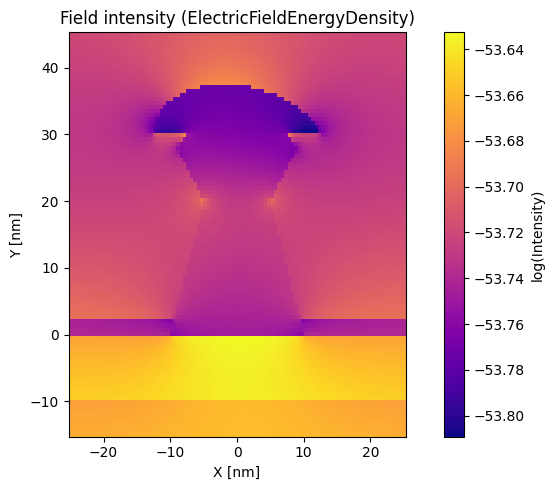

In [60]:
sim_results = SimulationResult.from_list(results)

for res in sim_results:
    print(res.summary())
    print("-" * 40)
    fd = res.field_data[0]  # your FieldData object
    fd.plot_field(index=0, log=True, cmap="plasma")

    fo = res.fourier[0].compute_order_intensities(orders_uni=[-1, 0, 1])
    print("Orders:", fo["orders"])
    print("Raw intensities:", fo["raw"])
    print("Corrected intensities:", fo["corrected"])

df = res.fourier[0].to_dataframe()


In [ ]:
all_dfs = []

# Suppose you have a list of SimulationResult objects
sim_results = SimulationResult.from_list(results)

for i, res in enumerate(sim_results):
    print(res.summary())
    print("-" * 40)

    # Plot first field export
    # fd = res.field_data[0]
    # fd.plot_field(index=0, log=True, cmap="plasma")

    # Fourier analysis
    fo = res.fourier[0].compute_order_intensities(orders_uni=[-1, 0, 1])
    # print("Orders:", fo["orders"])
    # print("Raw intensities:", fo["raw"])
    # print("Corrected intensities:", fo["corrected"])

    # Get DataFrame
    df = res.fourier[0].to_dataframe()

    # Add theta column from your external keys array
    df["theta"] = keys["Theta_unique"][i]

    # Collect
    all_dfs.append(df)

# Concatenate into one big DataFrame
df_all = pd.concat(all_dfs, ignore_index=True)

📂 SimulationResult from /tmp/__JCMwave__dfpo8u45/project_results/fieldbag.jcm
📊 ComputationalCosts: CPU=15.80s, Total=2.27s, Unknowns=557569
FieldData[0]: 🌐 FieldData: Quantity=ElectricFieldEnergyDensity, Shape=(100, 100, 1), Grid points=(100, 100)
Fourier[0]: 🔊 ElectricFieldStrength_PropagatingFourierCoefficients: NormalDirection=Y, K=(1, 3)
----------------------------------------


KeyError: 'Theta_unique'